# 02 - NF-HEDM forward rendering (3D Gaussian splatting)

Near-field HEDM records the *full diffraction images* on a detector placed
close to the sample, rather than reducing each reflection to a spot
coordinate. `midas-diffract` produces this output mode with
`HEDMForwardModel.predict_images()`, which splats every valid reflection as a
3D Gaussian blob onto the `(frame, y, z)` detector volume.

This example:

1. Builds a small near-field geometry whose Debye-Scherrer rings land on a
   256x256 detector.
2. Generates an alpha-Fe (BCC) reflection list with `midas-hkls`.
3. Forward-simulates a single grain and renders the image volume.
4. Confirms gradients flow back through the splatting to the orientation.

Everything runs on CPU on a tiny synthetic grid - no C binaries, no real
data. For the FF-HEDM spot-coordinate mode and gradient-based recovery see
`01_ff_pixel_exact.ipynb`.

**Setup:**
```bash
pip install midas-diffract[hkls]    # pulls in midas-hkls
```

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import math

import torch

import midas_diffract as md
from midas_hkls import Lattice, SpaceGroup

DEG2RAD = math.pi / 180.0
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

## Reflection list (alpha-Fe, BCC, space group 229)

`hkls_for_forward_model` wraps `midas_hkls.generate_hkls`, expands each ASU
representative to its symmetry equivalents, and returns the Cartesian
G-vectors plus Bragg angles in the convention the forward model expects.

In [2]:
sg = SpaceGroup.from_number(229)                 # BCC
lat = Lattice.for_system('cubic', a=2.87)          # alpha-Fe
wavelength = 0.295                                  # Angstroms

hkls_cart, thetas, hkls_int = md.hkls_for_forward_model(
    sg, lat,
    wavelength_A=wavelength,
    two_theta_max_deg=18.0,
)
two_theta_deg = (2 * thetas) / DEG2RAD
print(f'{hkls_cart.shape[0]} reflections, 2theta up to '
      f'{two_theta_deg.max().item():.2f} deg')

54 reflections, 2theta up to 16.72 deg


## Near-field geometry

We size the sample-to-detector distance so the innermost ring lands well
inside a 256x256 detector. Near-field detectors sit close to the sample, so
the rings are large relative to the FF case - here `Lsd` is chosen to keep
the first four rings on the active area. The omega scan covers 360 deg in
120 frames of 3 deg each.

In [3]:
NY = NZ = 256
px = 1.48                                            # detector pixel size (um)
n_frames = 120

# Place the innermost ring at ~55 px: Lsd = R * px / tan(2theta_min)
tt_min = 2 * thetas.min()
Lsd = 55.0 * px / math.tan(float(tt_min))

geom = md.HEDMGeometry(
    Lsd=Lsd,
    y_BC=NY / 2.0, z_BC=NZ / 2.0,
    px=px,
    omega_start=0.0, omega_step=3.0, n_frames=n_frames,
    n_pixels_y=NY, n_pixels_z=NZ,
    min_eta=6.0,
    wavelength=wavelength,
    flip_y=False,
)
ring_px = Lsd * torch.tan(2 * thetas) / px
print(f'Lsd = {Lsd:.1f} um, ring radii (px): '
      f'{[round(r, 1) for r in ring_px.tolist()[:4]]}')
geom

Lsd = 555.5 um, ring radii (px): [55.0, 55.0, 55.0, 55.0]


HEDMGeometry(Lsd=555.5288184454919, y_BC=128.0, z_BC=128.0, px=1.48, omega_start=0.0, omega_step=3.0, n_frames=120, n_pixels_y=256, n_pixels_z=256, min_eta=6.0, wavelength=0.295, tx=0.0, ty=0.0, tz=0.0, flip_y=False, wedge=0.0, apply_tilts=False, multi_mode='layered')

## Forward model + single grain

In [4]:
model = md.HEDMForwardModel(
    hkls=hkls_cart,
    thetas=thetas,
    geometry=geom,
    hkls_int=hkls_int,
)

euler = torch.tensor([6.0, 11.0, 17.0]) * DEG2RAD   # a small tilt off the axis
position = torch.zeros(3)                            # grain at the origin

spots = model(euler.unsqueeze(0), position.unsqueeze(0))
n_valid = int(spots.valid.sum().item())
print(f'{n_valid} valid reflections land on the detector')

54 valid reflections land on the detector


## Render the 3D image volume

`predict_images` returns a `(n_frames, n_pixels_y, n_pixels_z)` tensor. Each
valid spot becomes a Gaussian blob of width `sigma` (pixels) truncated at
`radius` pixels. The render is fully differentiable.

In [5]:
images = md.HEDMForwardModel.predict_images(
    spots,
    n_frames=n_frames, n_pixels_y=NY, n_pixels_z=NZ,
    sigma=1.0, radius=3,
)
frame_intensity = images.sum(dim=(1, 2))
lit_frames = torch.nonzero(frame_intensity > 0).flatten()
print(f'image volume {tuple(images.shape)}  '
      f'({images.numel() * 8 / 1e6:.0f} MB)')
print(f'total splatted intensity = {float(images.sum()):.2f}')
print(f'{lit_frames.numel()} frames carry signal: '
      f'{lit_frames.tolist()[:8]} ...')

image volume (120, 256, 256)  (63 MB)
total splatted intensity = 849.29
63 frames carry signal: [0, 1, 2, 3, 4, 5, 6, 7] ...


## Inspect the brightest frame

We pull out the single most intense omega frame and report where its blob
sits on the detector. (matplotlib is optional - the cell prints the same
information if it is not installed.)

brightest frame #9 at omega = 27.0 deg, peak pixel (y=196, z=59)


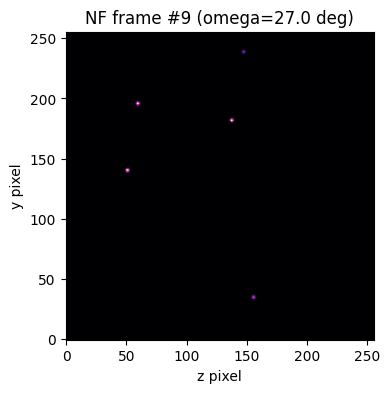

In [6]:
best = int(torch.argmax(frame_intensity))
frame = images[best]
iy, iz = torch.unravel_index(torch.argmax(frame), frame.shape)
omega = geom.omega_start + best * geom.omega_step
print(f'brightest frame #{best} at omega = {omega:.1f} deg, '
      f'peak pixel (y={int(iy)}, z={int(iz)})')

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(frame.detach().numpy(), origin='lower', cmap='magma')
    ax.set_title(f'NF frame #{best} (omega={omega:.1f} deg)')
    ax.set_xlabel('z pixel'); ax.set_ylabel('y pixel')
    plt.show()
except ImportError:
    print('(matplotlib not installed - skipping image)')

## Gradient sanity check

The whole render is differentiable: a scalar reduction of the image volume
produces finite gradients on the grain orientation, which is what makes
image-space NF reconstruction by gradient descent possible.

In [7]:
euler_g = euler.clone().requires_grad_(True)
spots_g = model(euler_g.unsqueeze(0), position.unsqueeze(0))
images_g = md.HEDMForwardModel.predict_images(
    spots_g, n_frames=n_frames, n_pixels_y=NY, n_pixels_z=NZ,
    sigma=1.0, radius=3,
)
images_g.sum().backward()
print('d(sum images)/d(euler):', euler_g.grad)
assert torch.isfinite(euler_g.grad).all()
assert euler_g.grad.abs().sum() > 0

d(sum images)/d(euler): tensor([4.0834, 2.0880, 4.7155])


The non-zero, finite gradient confirms the splatting path stays
end-to-end differentiable: rotating the grain moves the rendered blobs, and
torch can trace that all the way back to the three Euler angles. This is the
NF analogue of the FF spot-coordinate recovery in `01_ff_pixel_exact.ipynb`.